In [1]:
from homicsx.core import(
    GeometryInput,
    PhysicalTags,
    MeshSettings,
    MaterialAssignment,
    LinearElasticIsotropic,
    ProblemSettings,
)
from homicsx.geometry import patriculate_geometry_generator
from homicsx.stochastic import perform_ensemble_study
from homicsx.visualization import visualize_geometry

import matplotlib.pyplot as plt

Setting up the neccessary inputs/settings

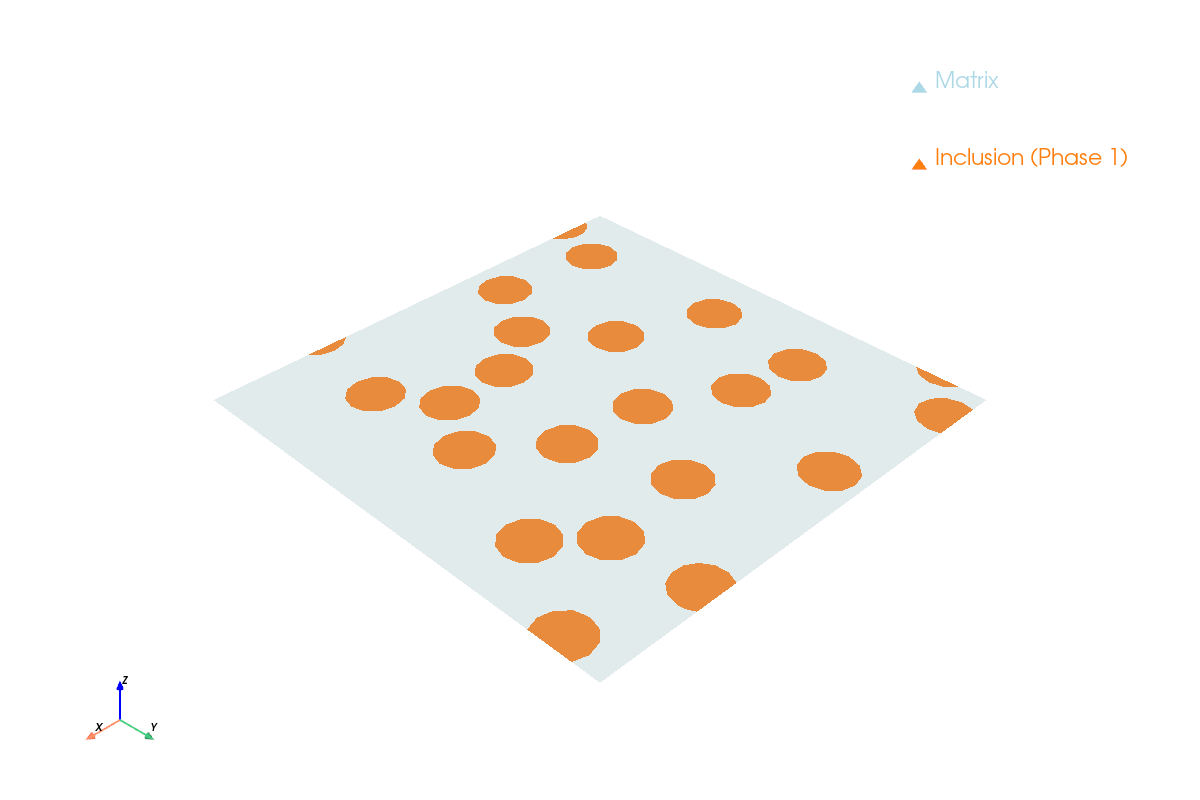

In [2]:
geometry_settings = GeometryInput(
    dim=2,
    dispersion='mono',
    volume_fraction=0.2,
    num_particles=20,
    clearance=0.015,
    domain_size=(1, 1),
    shape='circle',
    seed=42,
)

visualize_geometry(
    geometry=patriculate_geometry_generator(
        input_data=geometry_settings
    )
)

E_mat = 1.0
nu_mat = 0.3
mat_matrix = LinearElasticIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 100.0
nu_inc = 0.3
mat_particle = LinearElasticIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

fem_settings = ProblemSettings(
    dim=geometry_settings.dim,
    kinematics='small_strain',
    two_dimensional_formulation='plane_strain',
    element_family='Lagrange',
    element_degree=1,
)

Running the convergence loop

In [3]:
mesh_size_list = [(0.09, 0.08), (0.085, 0.075), (0.08, 0.07), (0.07, 0.06), (0.06, 0.05), (0.05, 0.04), (0.04, 0.03), (0.03, 0.02)]

mesh_mean_size_list = []
for ms in mesh_size_list:
    mesh_mean_size_list.append((ms[1]+ms[0])/2)

E_mean_list = []
for mesh_size in mesh_size_list:
    mesh_settings = MeshSettings(
        min_size=mesh_size[0],
        max_size=mesh_size[1],
    )

    result = perform_ensemble_study(
        ensemble_size=3,
        geometry_input=geometry_settings,
        mesh_settings=mesh_settings,
        Physical_tags=PhysicalTags(),
        assignment=material_assignment,
        fem_settings=fem_settings,
        matrix_phase_id=0,
        homogenization_solver='linear',
        homogenization_mode='partial',
    )

    E_mean = result.result_summary.engineering_moduli_mean['E']
    E_mean_list.append(E_mean)

Post-processing

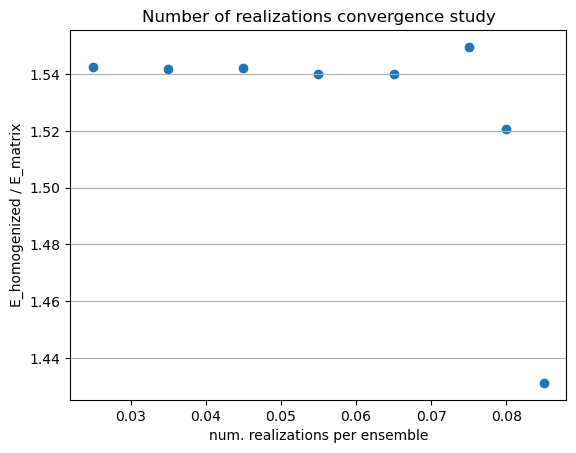

In [4]:
plt.scatter(mesh_mean_size_list, E_mean_list, marker='o')
plt.title('Number of realizations convergence study')
plt.xlabel('num. realizations per ensemble')
plt.ylabel('E_homogenized / E_matrix')
plt.grid(visible=True, which='major', axis='y')
plt.show()